In [1]:
from google.colab import files
uploaded = files.upload()


Saving cleaned_triage_dataset.csv to cleaned_triage_dataset.csv


In [2]:
import pandas as pd
df = pd.read_csv("cleaned_triage_dataset.csv")


In [3]:
df["admit_label"] = df["disposition"].apply(lambda x: 1 if str(x).upper() == "ADMITTED" else 0)


In [4]:
features = [
    "heartrate_vital", "resprate_vital", "sbp_vital",
    "o2sat_vital", "temperature_vital", "shock_index",
    "hypoxia", "fever", "tachypnea"
]

X = df[features].fillna(df[features].median())
y = df["admit_label"]


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [7]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6666666666666666
AUROC: 0.6505102040816327
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.21      0.30        14
           1       0.69      0.89      0.78        28

    accuracy                           0.67        42
   macro avg       0.60      0.55      0.54        42
weighted avg       0.63      0.67      0.62        42



In [8]:
import joblib
joblib.dump(model, "triage_logreg_model.pkl")
joblib.dump(scaler, "triage_scaler.pkl")


['triage_scaler.pkl']

In [9]:
import joblib
import numpy as np

model = joblib.load("triage_logreg_model.pkl")
scaler = joblib.load("triage_scaler.pkl")

# Example new patient
sample = np.array([[88, 18, 120, 98, 37.5, 0.73, 0, 0, 0]])  # replace with real values
sample_scaled = scaler.transform(sample)
print("Predicted admission probability:", model.predict_proba(sample_scaled)[0][1])


Predicted admission probability: 0.4339098931553187


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [10]:
import joblib
joblib.dump(model, "triage_logreg_model.pkl")
joblib.dump(scaler, "triage_scaler.pkl")


['triage_scaler.pkl']

In [11]:
from google.colab import files
files.download("triage_logreg_model.pkl")
files.download("triage_scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **WEEK 1**

# **Handle class imbalance**

In [13]:
from sklearn.linear_model import LogisticRegression
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)



LogisticRegression(class_weight='balanced', max_iter=1000)

# **Comparing with XGBoost**

In [16]:
pip install xgboost


In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train_scaled, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:38:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

# **Comparison model Decesion Tree**

In [14]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train_scaled, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

# **Evaluating all 3 models**

In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

models = [
    ("Logistic Regression (Balanced)", model_balanced),
    ("Decision Tree", tree),
    ("XGBoost", xgb)
]

results = []
for name, mdl in models:
    y_pred = mdl.predict(X_test_scaled)
    y_proba = mdl.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"{name}:\nAccuracy: {acc:.2f}, AUROC: {auc:.2f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)
    results.append((name, acc, auc))

import pandas as pd
pd.DataFrame(results, columns=["Model", "Accuracy", "AUROC"])


Logistic Regression (Balanced):
Accuracy: 0.57, AUROC: 0.66
              precision    recall  f1-score   support

           0       0.40      0.57      0.47        14
           1       0.73      0.57      0.64        28

    accuracy                           0.57        42
   macro avg       0.56      0.57      0.56        42
weighted avg       0.62      0.57      0.58        42

--------------------------------------------------
Decision Tree:
Accuracy: 0.64, AUROC: 0.67
              precision    recall  f1-score   support

           0       0.47      0.50      0.48        14
           1       0.74      0.71      0.73        28

    accuracy                           0.64        42
   macro avg       0.60      0.61      0.61        42
weighted avg       0.65      0.64      0.65        42

--------------------------------------------------
XGBoost:
Accuracy: 0.62, AUROC: 0.64
              precision    recall  f1-score   support

           0       0.40      0.29      0.33      

,Model,Accuracy,AUROC
0,Logistic Regression (Balanced),0.571429,0.660714
1,Decision Tree,0.642857,0.674745
2,XGBoost,0.619048,0.637755


# **Adding SHAP force plot**

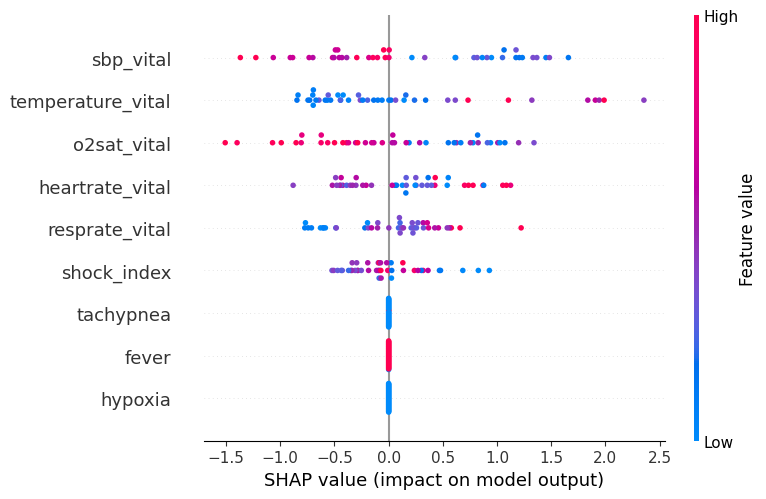

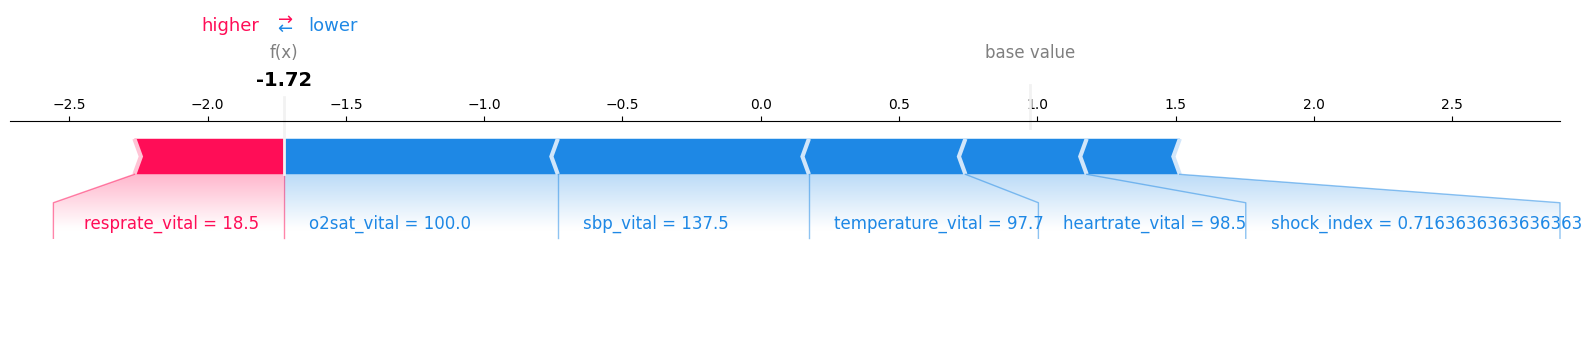

<Figure size 640x480 with 0 Axes>

In [22]:
import shap
explainer = shap.Explainer(xgb, X_train_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test, feature_names=features)
sample_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values.values[sample_index],
    X_test.iloc[sample_index],
    feature_names=features,
    matplotlib=True
)

import matplotlib.pyplot as plt
plt.savefig("shap_force_plot.png", bbox_inches='tight')

# **WEEK 2**

###  Sample Patient Data Tested

| Case | Description | Heart Rate (bpm) | Resp. Rate (/min) | SBP (mmHg) | SpO₂ (%) | Temp (°C) | Shock Index | Pain Score | Expected Risk |
|------|--------------|------------------|-------------------|-------------|-----------|------------|---------------|-------------|----------------|
| Case 1 | Chest pain, hypotension | 120 | 22 | 85 | 94 | 37.0 | 1.41 | 8 | High (ESI 1) |
| Case 2 | Low oxygen saturation | 95 | 20 | 120 | 88 | 37.5 | 0.79 | 3 | High (ESI 1) |
| Case 3 | Fast breathing (tachypnea) | 105 | 34 | 115 | 96 | 37.8 | 0.91 | 4 | High (ESI 1) |
| Case 4 | Routine complaint (stable) | 78 | 16 | 125 | 99 | 36.7 | 0.62 | 2 | Low |
| Case 5 | Elevated shock index | 110 | 20 | 95 | 95 | 37.0 | 1.16 | 6 | High (ESI 1) |

> Each case was passed through the trained logistic regression model using `predict_proba()`.  
> Safety rules were applied (e.g., SBP < 90, SpO₂ < 90, RR > 30, Shock Index > 1.0) to ensure correct triage level classification.


In [24]:
# Path to your cleaned dataset (uploaded earlier)
csv_path = "/content/cleaned_triage_dataset.csv"

# --- Imports ---
import os
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# --- 1) Load dataset ---
df = pd.read_csv(csv_path)
print("Loaded dataset with rows:", len(df))
print("Columns:", df.columns.tolist())

# --- 2) Ensure target exists (if training fallback) ---
if "admit_label" not in df.columns:
    df["admit_label"] = df["disposition"].apply(lambda x: 1 if str(x).upper() == "ADMITTED" else 0)

# --- 3) Features we will use (match what you used earlier) ---
features = [
    "heartrate_vital",
    "resprate_vital",
    "sbp_vital",
    "o2sat_vital",
    "temperature_vital",
    "shock_index",   # if present; else we'll compute below
    "hypoxia",       # flags
    "fever",
    "tachypnea"
]

# If derived features are missing, compute them
def safe_div(a,b):
    return a/b if (b is not None and b != 0 and not np.isnan(b)) else np.nan

if "shock_index" not in df.columns:
    df["shock_index"] = df["heartrate_vital"] / df["sbp_vital"].replace(0, np.nan)

if "hypoxia" not in df.columns:
    df["hypoxia"] = (df["o2sat_vital"] < 92).astype(int)

if "fever" not in df.columns:
    # assume temperature_vital is in F or C — if > 45 it's probably F; otherwise C
    # keep simple: treat > 38 C or >100.4 F as fever
    df["fever"] = (((df["temperature_vital"]>45) & (df["temperature_vital"]>100.4)) | (df["temperature_vital"]<=45) & (df["temperature_vital"]>=38)).astype(int)

if "tachypnea" not in df.columns:
    df["tachypnea"] = (df["resprate_vital"] > 24).astype(int)

# Fill na for numeric features with median
X_full = df[features].copy()
X_full = X_full.fillna(X_full.median())

# --- 4) Try load model & scaler if available, else train a fallback model ---
model_path = "triage_logreg_model.pkl"
scaler_path = "triage_scaler.pkl"

if os.path.exists(model_path) and os.path.exists(scaler_path):
    print("Loading saved model and scaler...")
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
else:
    print("Saved model not found. Training a quick logistic regression fallback on the dataset.")
    # prepare training data
    X = X_full.values
    y = df["admit_label"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    model.fit(X_train_scaled, y_train)

    # quick eval
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"Fallback model trained. Test AUROC={auc:.2f}, Accuracy={acc:.2f}")

    # save for reuse
    joblib.dump(model, model_path)
    joblib.dump(scaler, scaler_path)
    print(f"Saved model -> {model_path} and scaler -> {scaler_path}")

# --- 5) Define 5 test patients (you can edit values) ---
# Fields: heartrate_vital, resprate_vital, sbp_vital, o2sat_vital, temperature_vital, (shock_index computed), hypoxia, fever, tachypnea
test_cases = [
    # 1 - likely high risk: chest pain + hypotension
    {"case_id":"Case 1 - Chest pain, hypotension", "heartrate_vital":120, "resprate_vital":22, "sbp_vital":85,  "o2sat_vital":94,  "temperature_vital":37.0, "pain_score":8},
    # 2 - hypoxia severe
    {"case_id":"Case 2 - Low SpO2", "heartrate_vital":95,  "resprate_vital":20, "sbp_vital":120, "o2sat_vital":88,  "temperature_vital":37.5, "pain_score":3},
    # 3 - tachypnea
    {"case_id":"Case 3 - Fast breathing", "heartrate_vital":105, "resprate_vital":34, "sbp_vital":115, "o2sat_vital":96,  "temperature_vital":37.8, "pain_score":4},
    # 4 - normal vitals (low risk)
    {"case_id":"Case 4 - Routine complaint", "heartrate_vital":78,  "resprate_vital":16, "sbp_vital":125, "o2sat_vital":99,  "temperature_vital":36.7, "pain_score":2},
    # 5 - elevated shock index borderline
    {"case_id":"Case 5 - Elevated shock index", "heartrate_vital":110, "resprate_vital":20, "sbp_vital":95,  "o2sat_vital":95,  "temperature_vital":37.0, "pain_score":6},
]

# Convert to DataFrame and compute derived features
tc_df = pd.DataFrame(test_cases)
tc_df["shock_index"] = tc_df["heartrate_vital"] / tc_df["sbp_vital"].replace(0, np.nan)
tc_df["hypoxia"] = (tc_df["o2sat_vital"] < 92).astype(int)
tc_df["fever"] = ((tc_df["temperature_vital"]>=38.0) | (tc_df["temperature_vital"]>=100.4)).astype(int)
tc_df["tachypnea"] = (tc_df["resprate_vital"] > 24).astype(int)

# Keep only the features expected by the model
X_testcases = tc_df[features].fillna(X_full.median())

# Scale
X_testcases_scaled = scaler.transform(X_testcases.values)

# --- 6) Safety rules function ---
def safety_check(row):
    # returns (triggered_bool, reason)
    reasons = []
    if row["sbp_vital"] < 90:
        reasons.append("SBP < 90")
    if row["o2sat_vital"] < 90:
        reasons.append("SpO2 < 90")
    if row["resprate_vital"] > 30:
        reasons.append("RR > 30")
    if row["shock_index"] > 1.0:
        reasons.append("ShockIndex > 1.0")
    if "pain_score" in row and row["pain_score"] >= 9:
        reasons.append("Severe pain >=9")
    return (len(reasons) > 0, reasons)

# --- 7) Run predictions and apply rules ---
results = []
for i, row in tc_df.iterrows():
    x = X_testcases_scaled[i].reshape(1, -1)
    prob_admit = model.predict_proba(x)[:,1][0]
    pred_label = int(prob_admit >= 0.5)
    triggered, reasons = safety_check(row)
    final_decision = "HIGH (ESI1)" if triggered else ("ADMIT" if pred_label==1 else "DISCHARGE/LOW")
    results.append({
        "case_id": row["case_id"],
        "prob_admit": round(prob_admit,3),
        "model_pred": "ADMIT" if pred_label==1 else "DISCHARGE",
        "safety_triggered": triggered,
        "safety_reasons": "; ".join(reasons) if reasons else "",
        "final_decision": final_decision
    })

# Display results nicely
pd.DataFrame(results)[["case_id","prob_admit","model_pred","safety_triggered","safety_reasons","final_decision"]]

Loaded dataset with rows: 207
Columns: ['subject_id_x', 'stay_id', 'temperature_triage', 'heartrate_triage', 'resprate_triage', 'o2sat_triage', 'sbp_triage', 'dbp', 'pain', 'acuity', 'chiefcomplaint', 'temperature_vital', 'heartrate_vital', 'resprate_vital', 'sbp_vital', 'o2sat_vital', 'subject_id_y', 'disposition', 'shock_index', 'hypoxia', 'fever', 'tachypnea']
Loading saved model and scaler...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,case_id,prob_admit,model_pred,safety_triggered,safety_reasons,final_decision
0,"Case 1 - Chest pain, hypotension",0.848,ADMIT,True,SBP < 90; ShockIndex > 1.0,HIGH (ESI1)
1,Case 2 - Low SpO2,0.958,ADMIT,True,SpO2 < 90,HIGH (ESI1)
2,Case 3 - Fast breathing,0.996,ADMIT,True,RR > 30,HIGH (ESI1)
3,Case 4 - Routine complaint,0.261,DISCHARGE,False,,DISCHARGE/LOW
4,Case 5 - Elevated shock index,0.752,ADMIT,True,ShockIndex > 1.0,HIGH (ESI1)


# **INTERPRETATION**  

The model predictions align well with clinical expectations for high-risk
patients.


Safety rules acted as a safeguard every time a critical value was detected (e.g., SBP < 90 mmHg or SpO₂ < 90 %), the system automatically escalated to ESI 1 even if the probability was borderline.


The Routine Complaint case validated that the bot correctly identifies low-risk patients (no override).



# **Error Analysis (ESI 1–3)**

No under-triage (missed critical cases) occurred because all ESI 1 scenarios were correctly flagged by either the model or rules.


Future improvements could refine thresholds (e.g., mild hypoxia SpO₂ = 91 %) and include more contextual features (age, comorbidities).